# L-Maze: DQN

## Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* `gym-classics2` (see [Installation instructions](../common/Setup_gym_classics2.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics2
gym_classics2.register('gymnasium')

## Define A L-Maze Grid World 

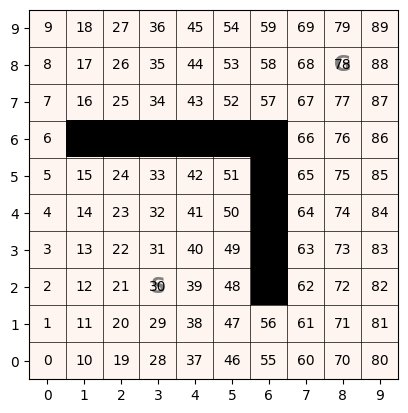

In [3]:
gym_env = gym.make('LMaze-v0', tabular = False)
env = gym_env.unwrapped

env.image()

In [4]:
%pip install -q stable-baselines3[extra] tqdm rich ipywidgets


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Set Up the DQN

In [5]:
from stable_baselines3 import DQN
from stable_baselines3.common.utils import LinearSchedule

log_dir = "./tb_logs/"


model = DQN(
        "MlpPolicy",
        env,
        gamma=0.9,
        target_update_interval=500,
        learning_rate=LinearSchedule(0.01,0.0001,.7),
        buffer_size=2000,  # buffer size is in samples
        exploration_fraction=.5,
        exploration_initial_eps=1.0,
        exploration_final_eps=.1,
        batch_size=32,
        tensorboard_log=log_dir,
        verbose = 0
    )



**Note:** 
* I played quite a lot with the parameters using TensorBoard (see below).
* Learning destabilizes if the learning rate is not reduced over time.

## Train the DQN

Stable-Baslines3 supports TensorBoard to monitor the training process. Open the terminal (e.g., in VS Code) and execute

``tensorboard --logdir ./tb_logs/``

Open your web browser to the URL as instructed in the terminal.

**Note:** you may have to change to the directory where your notebook is before you start TensorBoard

**Additional note:** 
* TensorBoard reports as `rollout/ep_rew_mean` the _undiscounted_ return so it is almost always just 1 for this problem.
* Since we want to find the shortest path, we look at `rollout/ep_len_mean` to see if the model gets better.

In [6]:
# total_timesteps (int) – The total number of samples (env steps) to train on. For comparison we use the data for 1000 episodes: 15 (opt. path length) * 2000
model.learn(total_timesteps=15 * 1000, log_interval=1, progress_bar=True)

Output()

Resume training with a fixed epsilon and new learning rate. (`reset_num_timesteps=False`) is to resume TensorBoard. We don't do this here.

In [ ]:
# from stable_baselines3.common.utils import ConstantSchedule
# model.learning_rate = .001
# model.exploration_schedule = ConstantSchedule(.01)

In [ ]:
# model.learn(total_timesteps=15 * 1000, log_interval=1, progress_bar=True, reset_num_timesteps=False)

Output()

Load the TensorBoard logs to visualize the learning curve over time. 

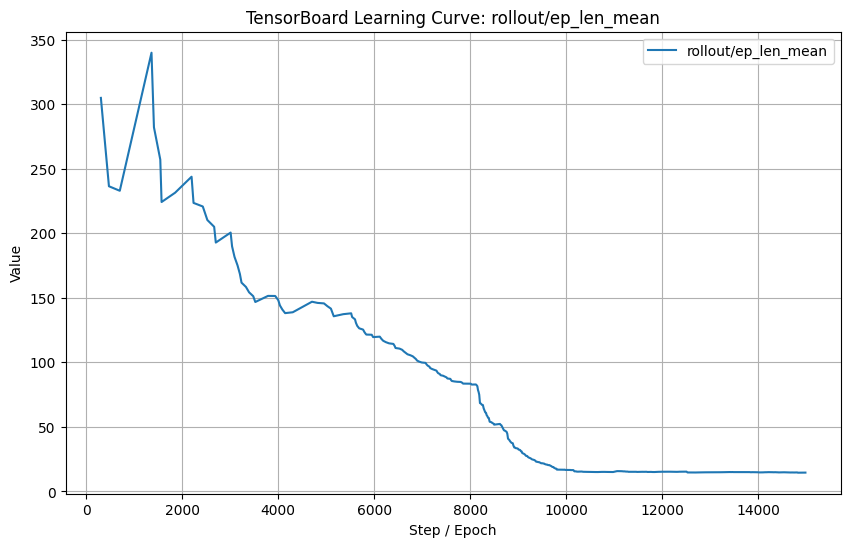

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

acc = EventAccumulator(log_dir + '/DQN_1/')
acc.Reload()
tag_name = 'rollout/ep_len_mean'  # Replace with the exact tag you want to plot
scalar_events = acc.Scalars(tag_name)
steps = np.array([e.step for e in scalar_events])
values = np.array([e.value for e in scalar_events])

plt.figure(figsize=(10, 6))
plt.plot(steps, values, label=tag_name)

plt.title(f'TensorBoard Learning Curve: {tag_name}')
plt.xlabel('Step / Epoch')
plt.ylabel('Value')
plt.grid()
plt.legend()
plt.show()

## Inspect the Learned Policy 

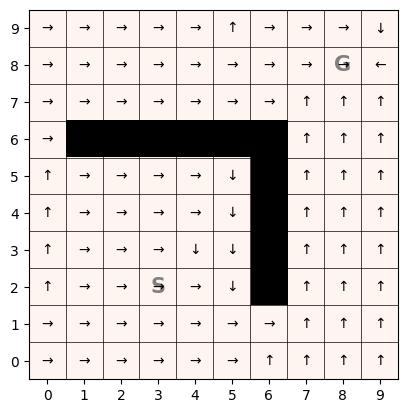

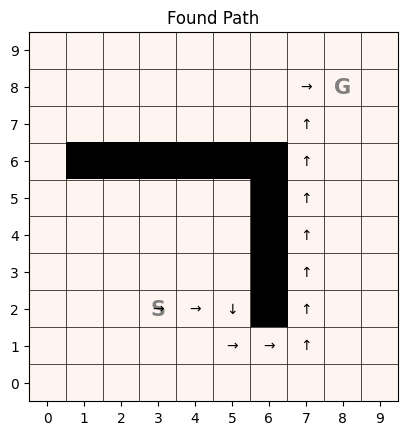

In [20]:
from gym_classics2.algorithms.monte_carlo_methods import sample_episode

pol = model.predict([env.id2state(s) for s in env.states()])[0]
env.image(policy = pol)

path_non_tabular = sample_episode(env, policy=pol, max_len=100)
path = [(env.state2id(s), a, r, env.state2id(sp)) for s, a, r, sp in path_non_tabular]
env.image(policy=pol, episode=path, title='Found Path')


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)